In [1]:
import torch

from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(
    encoder="text_sonar_basic_encoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)
        
sonar_v2t = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)

def get_sonar_embedding(text):
    with torch.no_grad():
        embedding = sonar_t2v.predict([text], source_lang="eng_Latn")
    return embedding

In [170]:
import torch
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

def calculate_clip_text_embeddings(texts):
    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
    text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
    return text_features

/home/jovyan/.mlspace/envs/spiridonov-sonar/lib/python3.11/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/home/jovyan/.mlspace/envs/spiridonov-sonar/lib/python3.11/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/home/jovyan/.mlspace/envs/spiridonov-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

## t-SNE

In [155]:
import os
import json
import colorsys
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np


def read_json_files(directory, file_limit=None):
    texts = []
    labels = []
    i = 1
    for filename in os.listdir(directory):
        if file_limit and i >= file_limit:
            break
        if filename.endswith('.json'):
            with open(os.path.join(directory, filename), 'r') as file:
                data = json.load(file)
                file_texts = data.get('text', [])
                if len(file_texts) < 2:
                    continue
                if any(len(text.split()) < 3 for text in file_texts):
                    continue
                texts.extend(file_texts)
                labels.extend([i] * len(file_texts))
                i += 1
    return texts, labels


def calculate_embeddings(texts, method='sonar'):
    if method == 'sonar':
        embeddings = []
        for text in tqdm(texts):
            embedding = get_sonar_embedding(text)
            embeddings.append(embedding.squeeze().cpu().numpy())
    elif method == 'clip':
        embeddings = calculate_clip_text_embeddings(texts)
    else:
        raise ValueError("Invalid method. Choose 'sonar' or 'clip'.")
    return np.array(embeddings)


def plot_tsne(embeddings, labels):
    perplexity = min(30, len(embeddings) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    reduced_embeddings = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 8))
    
    colormaps = ['tab10', 'tab20', 'Set3', 'Paired', 'Accent']

    colors = []
    for cmap_name in colormaps:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])

    colors = colors[:60]
    unique_labels = sorted(set(labels))
    
    for label in unique_labels:
        indices = [i for i, x in enumerate(labels) if x == label]
        plt.plot(reduced_embeddings[indices, 0],
                    reduced_embeddings[indices, 1],
                    label=f'File {label+1}',
                    marker='o',
                    markersize=2,
                    # s=15,
                    color=colors[label % 60],
                    alpha=0.3) 
    
    plt.title('t-SNE of Text Embeddings')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    # plt.legend()
    plt.savefig('tsne.png', dpi=300)
    plt.show()


def plot_pca(embeddings, labels):
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 8))
    
    colormaps = ['tab10', 'tab20', 'Set3', 'Paired', 'Accent']

    colors = []
    for cmap_name in colormaps:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])

    colors = colors[:60]
    unique_labels = sorted(set(labels))
    
    for label in unique_labels:
        indices = [i for i, x in enumerate(labels) if x == label]
        plt.plot(reduced_embeddings[indices, 0],
                 reduced_embeddings[indices, 1],
                 label=f'File {label+1}',
                 marker='o',
                 markersize=2,
                 color=colors[label % 60],
                 alpha=0.3) 
    
    plt.title('PCA of Text Embeddings')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.savefig('pca.png', dpi=300)
    plt.show()


def calculate_cosine_similarity(embeddings):
    similarities = np.dot(embeddings, embeddings.T)
    norms = np.linalg.norm(embeddings, axis=1)
    return similarities / np.outer(norms, norms)

### reason seg test

In [156]:
directory = '../../dataset/reason_seg/ReasonSeg/test'
texts, labels = read_json_files(directory)# , file_limit=0)

In [157]:
len(texts), len(labels) 

(3209, 3209)

### embedding correlation

In [69]:
def read_json_files(directory, file_limit=None):
    texts = []
    i = 1
    for filename in os.listdir(directory):
        if file_limit and i >= file_limit:
            break
        if filename.endswith('.json'):
            with open(os.path.join(directory, filename), 'r') as file:
                data = json.load(file)
                file_texts = data.get('text', [])
                texts.append(file_texts[0])
                i += 1
    return texts

In [70]:
directory = '../../dataset/reason_seg/ReasonSeg/test'
texts = read_json_files(directory)
print(len(texts))

779


In [80]:
def sonar_tokenize(text):
    return sonar_t2v.tokenizer.create_encoder(lang="eng_Latn")(text).tolist()

def sonar_decode(tokens):
    return str(sonar_t2v.tokenizer.create_decoder()(torch.tensor(tokens)))

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
import random

# --- 1. Compute embeddings and lengths ---
embed_lengths = []
for text in tqdm(texts):
    embedding = get_sonar_embedding(text).cpu().numpy()[0]
    length = len(sonar_tokenize(text))
    embed_lengths.append((length, embedding))

lengths = np.array([x[0] for x in embed_lengths])
embeddings = np.stack([x[1] for x in embed_lengths])  # shape (N, 768)

100%|██████████| 779/779 [00:06<00:00, 115.12it/s]


In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
embeddings_norm = scaler.fit_transform(embeddings)

Most correlated dim: 654, Pearson r = -0.956
Dimension 654: Pearson r=-0.956 (p=0.0e+00), Spearman ρ=-0.965, R²=0.913
Random dims avg correlation: 0.181 ± 0.117
Empirical permutation p-value: 0.0002


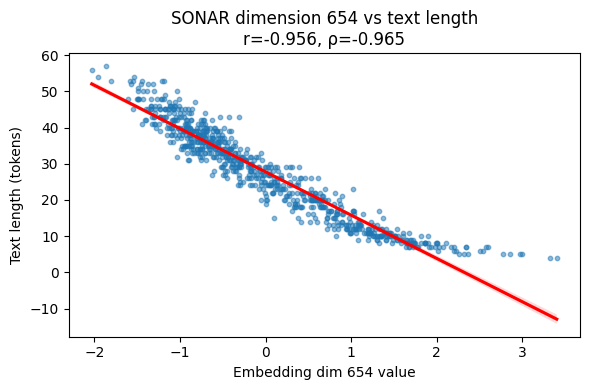

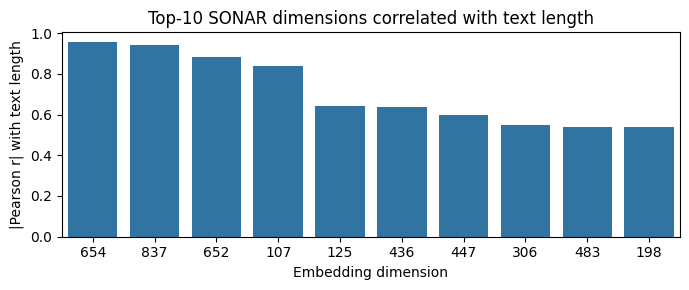

[87] dim=-2.031, len=56 → 'During the holiday season, children often have the opportunity to sit on someone'...
[461] dim=-0.789, len=37 → 'When driving a car, there are various indicators on the dashboard to provide inf'...
[32] dim=-0.260, len=32 → 'In the picture, the family is enjoying a water activity together. What object is'...
[358] dim=0.717, len=12 → 'the damaged part of the silk stockings'...
[432] dim=3.404, len=4 → 'the egg'...


In [89]:
# --- 2. Compute correlation of each embedding dim with text length ---
pearsons = []
for d in range(embeddings_norm.shape[1]):
    r, _ = pearsonr(embeddings_norm[:, d], lengths)
    pearsons.append(r)
pearsons = np.array(pearsons)

# Find dimension most correlated with length
d_star = int(np.argmax(np.abs(pearsons)))
r_star = pearsons[d_star]
print(f"Most correlated dim: {d_star}, Pearson r = {r_star:.3f}")

# --- 3. Compute detailed stats for that dimension ---
rho, p_s = spearmanr(embeddings_norm[:, d_star], lengths)
r, p_r = pearsonr(embeddings_norm[:, d_star], lengths)
lr = LinearRegression().fit(embeddings_norm[:, [d_star]], lengths)
r2 = lr.score(embeddings_norm[:, [d_star]], lengths)

print(f"Dimension {d_star}: Pearson r={r:.3f} (p={p_r:.1e}), Spearman ρ={rho:.3f}, R²={r2:.3f}")

# --- 4. Random-dim baseline and permutation test ---
random_dims = random.sample(range(embeddings_norm.shape[1]), 100)
rand_rs = [pearsonr(embeddings_norm[:, d], lengths)[0] for d in random_dims]
print(f"Random dims avg correlation: {np.mean(np.abs(rand_rs)):.3f} ± {np.std(np.abs(rand_rs)):.3f}")

# Permutation test for empirical p-value
nperm = 5000
perm_vals = []
for _ in range(nperm):
    perm = np.random.permutation(lengths)
    perm_vals.append(pearsonr(embeddings_norm[:, d_star], perm)[0])
emp_p = (np.sum(np.abs(perm_vals) >= np.abs(r)) + 1) / (nperm + 1)
print(f"Empirical permutation p-value: {emp_p:.4f}")

# --- 5. Visualization ---

# Bar plot of top-10 correlated dimensions
top_k = 10
top_dims = np.argsort(-np.abs(pearsons))[:top_k]
plt.figure(figsize=(7, 3))
sns.barplot(x=np.arange(top_k), y=np.abs(pearsons[top_dims]))
plt.xticks(np.arange(top_k), [f"{d}" for d in top_dims])
plt.xlabel("Embedding dimension")
plt.ylabel("|Pearson r| with text length")
plt.title("Top-10 SONAR dimensions correlated with text length")
plt.tight_layout()
plt.show()

# --- 6. Show qualitative examples ---
sorted_indices = np.argsort(embeddings_norm[:, d_star])
for idx in np.linspace(0, len(texts)-1, 5, dtype=int):
    i = sorted_indices[idx]
    print(f"[{i}] dim={embeddings_norm[i, d_star]:.3f}, len={lengths[i]} → {texts[i][:80]!r}...")


In [ ]:
for n in range(50, 750, 50):
    random_dims = random.sample(range(embeddings_norm.shape[1]), n)
    rand_rs = [pearsonr(embeddings_norm[:, d], lengths)[0] for d in random_dims]
    print(f"n = {n} \t Random dims avg correlation: {np.mean(np.abs(rand_rs)):.3f} ± {np.std(np.abs(rand_rs)):.3f}")


In [63]:
np.argsort(-np.abs(pearsons))[:top_k]

array([654, 837, 652, 107, 125, 436, 447, 306, 483, 198])

In [94]:
from sklearn.linear_model import LinearRegression

# Predict text length from top-k correlated dimensions
dims = [654, 837]
X = embeddings[:, dims]
y = lengths
lr = LinearRegression().fit(X, y)
print("R² using dims 654+837:", lr.score(X, y))


R² using dims 654+837: 0.9400591254234314


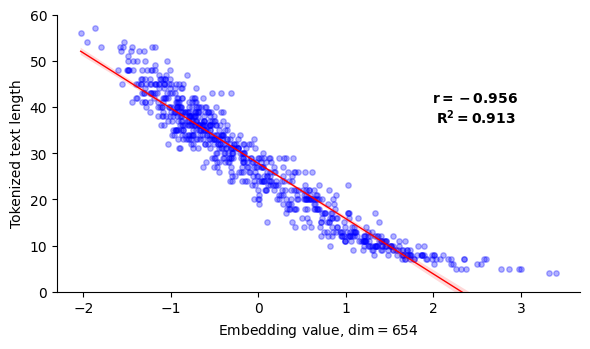

In [154]:
# Scatter plot
plt.figure(figsize=(6, 3.6))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_xlim(left=0)
ax.set_ylim(0, 60)

sns.regplot(x=embeddings_norm[:, d_star], y=lengths, scatter_kws={'alpha': 0.3, 's': 15, 'color': 'blue'}, line_kws={'color': 'red', 'linewidth': 1})
# plt.title(f"SONAR dimension {d_star} vs text length\nr={r:.3f}, ρ={rho:.3f}")
plt.xlabel(r"Embedding value, ${\text{dim} = 654}$")
plt.ylabel("Tokenized text length")
plt.text(0.8, 0.7, r"${\bf r=-0.956}$", ha='center', va='center', transform=ax.transAxes)
plt.text(0.8, 0.63, r"${\bf R^2=0.913}$", ha='center', va='center', transform=ax.transAxes)
plt.tight_layout()
plt.savefig('sonar_dim_654_vs_length.png', dpi=300)
plt.savefig('sonar_dim_654_vs_length.pdf', dpi=300)
plt.show()

### filtering

24.260517295107512


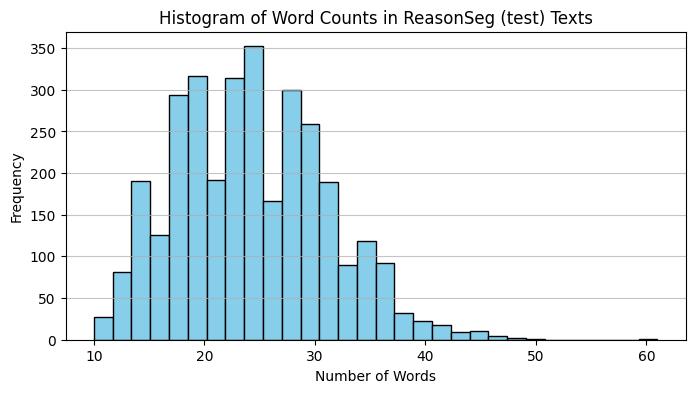

In [158]:
def plot_word_count_histogram(texts):
    word_counts = [len(text.split()) for text in texts]
    print(np.array(word_counts).mean())
    plt.figure(figsize=(8, 4))
    plt.hist(word_counts, bins=30, color='skyblue', edgecolor='black')
    plt.title('Histogram of Word Counts in ReasonSeg (test) Texts')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.savefig('word_count_histogram.png', dpi=300)
    plt.show()

plot_word_count_histogram(texts)

In [159]:
def filter_texts_by_group(texts, labels, l_max=None):
    if l_max is None: return
    from collections import defaultdict

    grouped_texts = defaultdict(list)
    for text, label in zip(texts, labels):
        grouped_texts[label].append(text)

    filtered_texts = []
    filtered_labels = []
    for label, group in grouped_texts.items():
        if all(len(text.split()) <= l_max for text in group):
            filtered_texts.extend(group)
            filtered_labels.extend([label] * len(group))

    return filtered_texts, filtered_labels


def filter_texts_by_word_count(texts, labels, word_count=None):
    if word_count is None: return
    from collections import defaultdict

    grouped_texts = defaultdict(list)
    for text, label in zip(texts, labels):
        grouped_texts[label].append(text)

    filtered_texts = []
    filtered_labels = []
    for label, group in grouped_texts.items():
        for text in group:
            words = text.split()
            if len(words) > word_count:
                words = words[:word_count]
            filtered_texts.append(' '.join(words))
            filtered_labels.append(label)
    return filtered_texts, filtered_labels

In [160]:
filtered_texts, filtered_labels = filter_texts_by_group(texts, labels, l_max=15)
print(f'{len(filtered_texts)} out of {len(texts)}')

74 out of 3209


In [161]:
for l_max in [15, 20, 25, 30, 35]:
    filtered_texts, filtered_labels = filter_texts_by_group(texts, labels, l_max=l_max)
    print(f'for l_max={l_max} \t {len(filtered_texts)} out of {len(texts)}')

for l_max=15 	 74 out of 3209
for l_max=20 	 397 out of 3209
for l_max=25 	 1060 out of 3209
for l_max=30 	 1941 out of 3209
for l_max=35 	 2668 out of 3209


In [13]:
embeddings = calculate_embeddings(filtered_texts, method='sonar')

100%|██████████| 1041/1041 [00:11<00:00, 89.61it/s] 


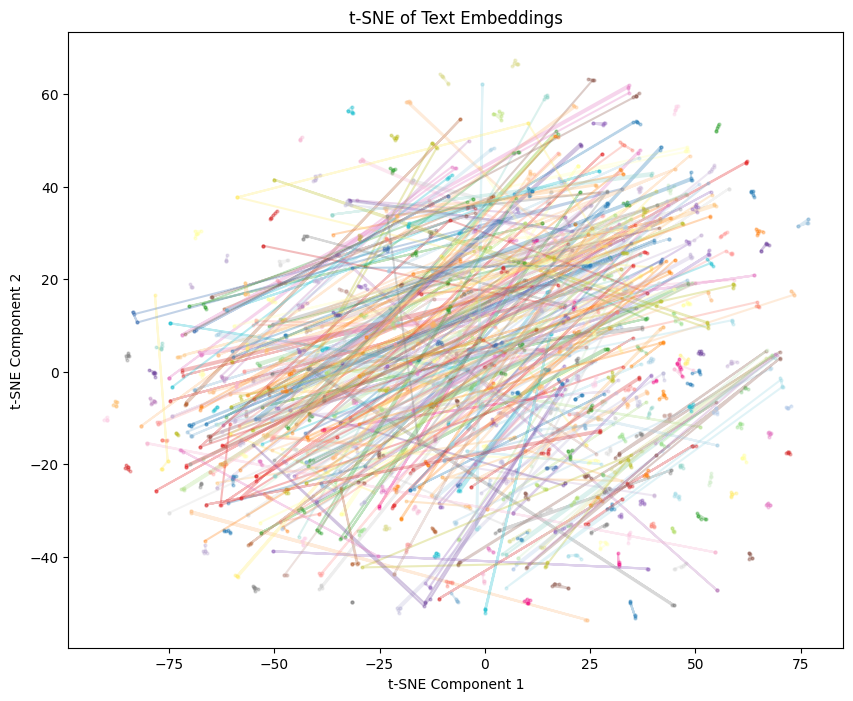

In [55]:
plot_tsne(embeddings, filtered_labels)

In [ ]:
plot_pca(embeddings, filtered_labels)

#### filter by word count

In [61]:
filtered_texts, filtered_labels = filter_texts_by_word_count(texts, labels, word_count=13)
print(f'{len(filtered_texts)} out of {len(texts)}')

3209 out of 3209


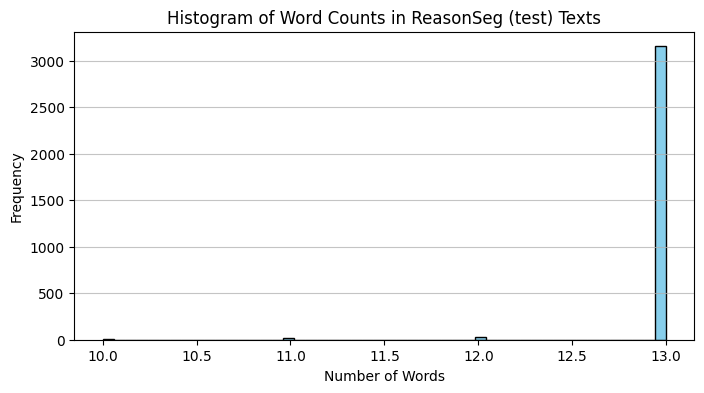

In [62]:
plot_word_count_histogram(filtered_texts)

In [ ]:
file_name='tsne_grid.png'

#### multiple plots

In [162]:
def calculate_embeddings_for_l_max(texts, labels, l_max_values, method_name='sonar', word_count=False):
    embeddings_list = []
    labels_list = []
    
    for l_max in tqdm(l_max_values):
        if word_count:
            filtered_texts, filtered_labels = filter_texts_by_word_count(texts, labels, word_count=l_max)
        else:
            filtered_texts, filtered_labels = filter_texts_by_group(texts, labels, l_max=l_max)
        embeddings = calculate_embeddings(filtered_texts, method=method_name)
        
        embeddings_list.append(embeddings)
        labels_list.append(filtered_labels)
    
    return embeddings_list, labels_list


def plot_multiple_tsne_grid(embeddings_list, labels_list, l_max_values, nrows, ncols, file_name='tsne_grid.png'):
    num_plots = len(l_max_values)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = axes.flatten() 

    for ax, embeddings, labels, l_max in zip(axes, embeddings_list, labels_list, l_max_values):
        plot_tsne(embeddings, labels, l_max, ax)

    for ax in axes[num_plots:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(file_name, dpi=300)
    plt.show()


def plot_tsne(embeddings, labels, l_max, ax):
    perplexity = min(30, len(embeddings) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    reduced_embeddings = tsne.fit_transform(embeddings)
    
    colormaps = ['tab10', 'tab20', 'Set3', 'Paired', 'Accent']

    colors = []
    for cmap_name in colormaps:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])

    colors = colors[:60]
    unique_labels = sorted(set(labels))
    
    for label in unique_labels:
        indices = [i for i, x in enumerate(labels) if x == label]
        ax.plot(reduced_embeddings[indices, 0],
                reduced_embeddings[indices, 1],
                label=f'File {label+1}',
                marker='o',
                markersize=2,
                color=colors[label % 60],
                alpha=0.5) 
    
    ax.set_title(f'max sentence length = {l_max}')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')

In [163]:
method = 'sonar'

In [164]:
# l_max_values = [13, 14, 15, 20, 25, 30, 35]
l_max_values = [20, 25, 30, 35]

embeddings_list, labels_list = calculate_embeddings_for_l_max(texts, labels, l_max_values, method_name=method)

100%|██████████| 4/4 [00:54<00:00, 13.56s/it]


In [165]:
def plot_multiple_tsne_grid(embeddings_list, labels_list, l_max_values, nrows, ncols, file_name='tsne_grid.png'):
    num_plots = len(l_max_values)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = axes.flatten() 

    for ax, embeddings, labels, l_max, letter in zip(axes, embeddings_list, labels_list, l_max_values, ['a', 'b', 'c', 'd']):
        plot_tsne(embeddings, labels, l_max, ax, letter)

    for ax in axes[num_plots:]:
        ax.set_visible(False)

    fig.supxlabel('t-SNE Dimension 1', fontsize=12, y=0.01)
    fig.supylabel('t-SNE Dimension 2', fontsize=12, x=0.01)

    plt.tight_layout()
    plt.savefig(file_name, dpi=300)
    plt.savefig(file_name.replace('.pdf', '.png'), dpi=300)
    plt.show()


def plot_tsne(embeddings, labels, l_max, ax, letter):
    perplexity = min(30, len(embeddings) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    reduced_embeddings = tsne.fit_transform(embeddings)
    
    colormaps = ['tab10', 'tab20', 'Set3', 'Paired', 'Accent']

    colors = []
    for cmap_name in colormaps:
        cmap = plt.get_cmap(cmap_name)
        colors.extend([cmap(i) for i in range(cmap.N)])

    colors = colors[:60]
    unique_labels = sorted(set(labels))
    
    for label in unique_labels:
        indices = [i for i, x in enumerate(labels) if x == label]
        ax.plot(reduced_embeddings[indices, 0],
                reduced_embeddings[indices, 1],
                label=f'File {label+1}',
                marker='o',
                markersize=2,
                color=colors[label % 60]) 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # ax.set_title(f'≤{l_max} words', fontweight='bold', fontsize=12)
    ax.set_title(f'({letter}) Sentences ≤ {l_max} Words', fontweight='bold')
    # ax.set_xlabel('t-SNE Component 1')
    # ax.set_ylabel('t-SNE Component 2')

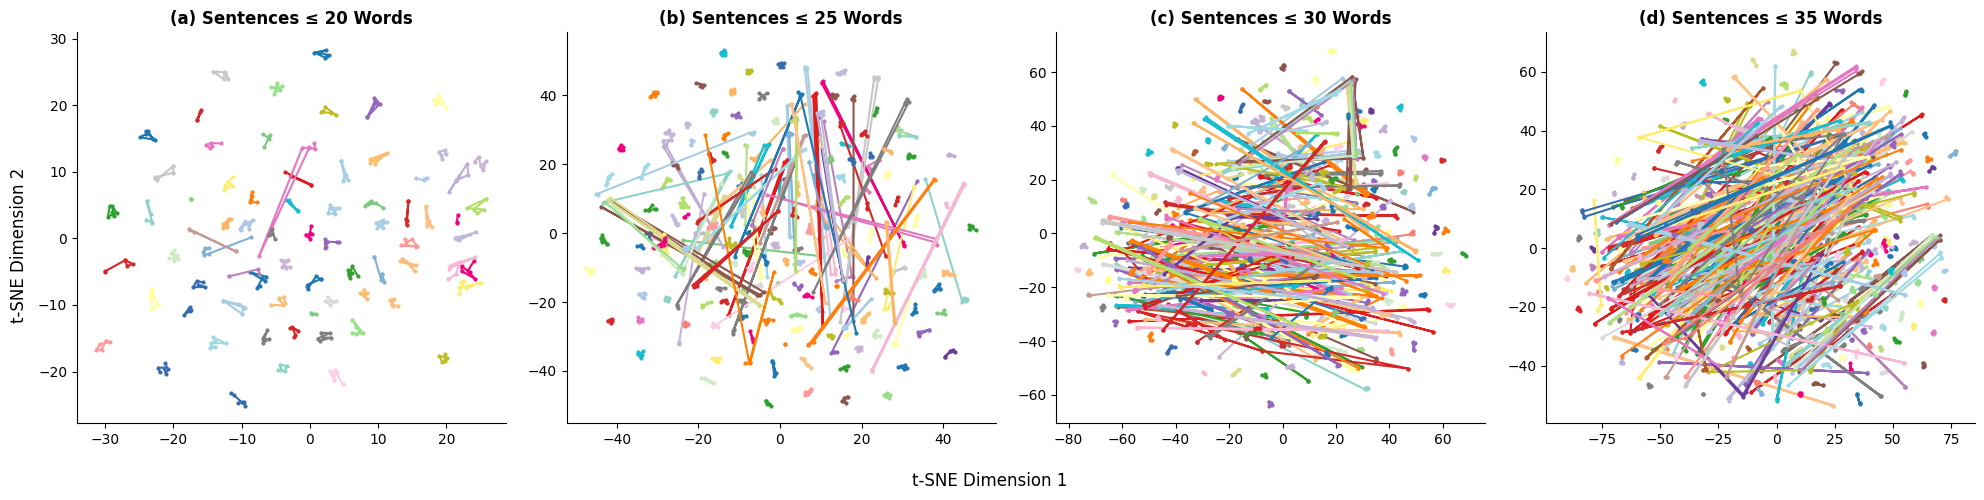

In [166]:
plot_multiple_tsne_grid(embeddings_list, labels_list, l_max_values, nrows=1, ncols=4, file_name=f'{method}_tsne_grid.pdf')

In [39]:
l_max_values = [13, 14, 15, 16, 20, 30]
embeddings_list, labels_list = calculate_embeddings_for_l_max(texts, labels, l_max_values, word_count=True)

100%|██████████| 3209/3209 [00:27<00:00, 114.68it/s]


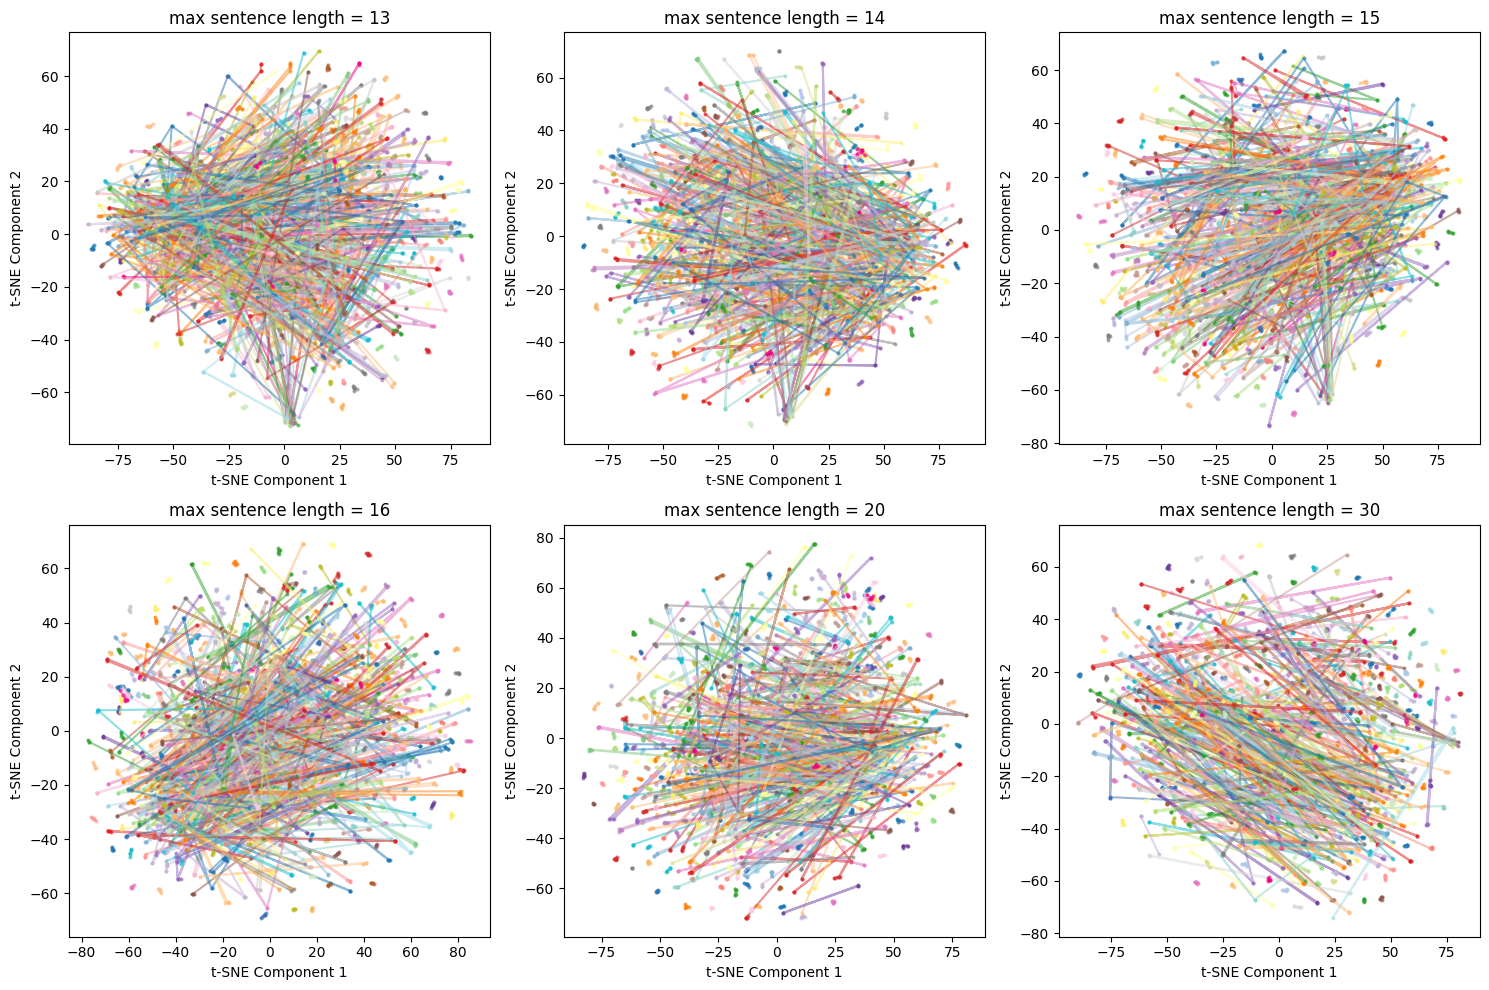

In [40]:
plot_multiple_tsne_grid(embeddings_list, labels_list, l_max_values, nrows=2, ncols=3, file_name='tsne_grid_word_count.png')

### Restoration Quality







#### Restoration quality for DeCap

In [72]:
with open('/home/jovyan/zinkovich/DeCap/dataset/coco_train.json', 'r') as json_file:
    texts = json.load(json_file)

In [67]:
def restore_text(embedding):
    decoded_text, _ = sonar_v2t.predict(torch.tensor(embedding).unsqueeze(0), target_lang="eng_Latn", max_seq_len=512)
    return decoded_text

In [74]:
embeddings = calculate_embeddings(texts[:1000], method='sonar')
embeddings.shape

100%|██████████| 1000/1000 [00:07<00:00, 125.88it/s]


(1000, 1024)

In [ ]:
restored_texts = []
original_texts = []

for text, embedding in tqdm(zip(texts[:1000], embeddings)):
    try:
        restored = restore_text(embedding)
        restored_texts.append(restored)
        original_texts.append(text)
    except Exception as e:
        print(f"Error in restoring text: {e}")
        continue
    # restored = restore_text(embedding)
    # restored_texts.append(restored)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Any, Optional
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from bert_score import BERTScorer
import warnings
import os
import json


class TextSimilarityEvaluator:

    def __init__(self, device: str = None):
        if device is None:
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = device
            
        print(f"Using device: {self.device}")
        
        try:
            nltk.data.find('tokenizers/punkt')
        except LookupError:
            nltk.download('punkt')
        
        self.rouge_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
        
        print("Loading BERTScore model...")
        self.bert_scorer = BERTScorer(lang="en", rescale_with_baseline=True, device=self.device)
        
        print("Loading BLEURT model...")
        self.bleurt_tokenizer = AutoTokenizer.from_pretrained("Elron/bleurt-base-512")
        self.bleurt_model = AutoModelForSequenceClassification.from_pretrained("Elron/bleurt-base-512").to(self.device)
            
        self.smoothing = SmoothingFunction().method1
    

    def calculate_bleu4(self, references: List[str], candidates: List[str]) -> Dict[str, float]:
        if len(references) != len(candidates):
            raise ValueError(f"Number of references ({len(references)}) and candidates ({len(candidates)}) must match")
            
        bleu4_scores = []
        tokenized_refs = []
        tokenized_cands = []
        
        for ref, cand in zip(references, candidates):
            ref_tokens = nltk.word_tokenize(ref.lower())
            cand_tokens = nltk.word_tokenize(cand.lower())
            
            tokenized_refs.append([ref_tokens]) 
            tokenized_cands.append(cand_tokens)
            
            bleu4_scores.append(sentence_bleu([ref_tokens], cand_tokens, 
                                            weights=(0.25, 0.25, 0.25, 0.25), 
                                            smoothing_function=self.smoothing))
        
        corpus_bleu4 = corpus_bleu(tokenized_refs, tokenized_cands, 
                                weights=(0.25, 0.25, 0.25, 0.25), 
                                smoothing_function=self.smoothing)
        return {
            'bleu4_avg': np.mean(bleu4_scores),
            'bleu4_corpus': corpus_bleu4
        }
    

    def calculate_rougeL(self, references: List[str], candidates: List[str]) -> Dict[str, float]:
        rougeL_p, rougeL_r, rougeL_f = [], [], []
        
        for ref, cand in zip(references, candidates):
            scores = self.rouge_scorer.score(ref, cand)
            
            rougeL_p.append(scores['rougeL'].precision)
            rougeL_r.append(scores['rougeL'].recall)
            rougeL_f.append(scores['rougeL'].fmeasure)
        
        result = {
            'rougeL_precision': np.mean(rougeL_p),
            'rougeL_recall': np.mean(rougeL_r),
            'rougeL_f1': np.mean(rougeL_f)
        }
        return result
    

    def calculate_bertscore(self, references: List[str], candidates: List[str]) -> Dict[str, float]:
        P, R, F1 = self.bert_scorer.score(candidates, references)
        return {
            'bertscore_precision': P.mean().item(),
            'bertscore_recall': R.mean().item(),
            'bertscore_f1': F1.mean().item()
        }
    

    def calculate_bleurt(self, references: List[str], candidates: List[str]) -> Dict[str, float]:
        bleurt_scores = []
        batch_size = 8
        for i in range(0, len(references), batch_size):
            batch_refs = references[i:i+batch_size]
            batch_cands = candidates[i:i+batch_size]
            
            inputs = self.bleurt_tokenizer(batch_refs, batch_cands, return_tensors="pt", padding=True, truncation=True, max_length=512)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            
            with torch.no_grad():
                scores = self.bleurt_model(**inputs).logits
            
            bleurt_scores.extend(scores.cpu().numpy().tolist())
        
        return {'bleurt': np.mean(bleurt_scores)}


    def visualize_results(self, results: Dict[str, Any], output_dir: str = "./results") -> None:
        os.makedirs(output_dir, exist_ok=True)
        
        metrics_to_plot = {
            'BLEU-4 (corpus)': results['bleu4_corpus'],
            'ROUGE-L (F1)': results['rougeL_f1'],
            'BERTScore (F1)': results['bertscore_f1'],
            'BLEURT': results['bleurt']
        }
        
        plt.figure(figsize=(10, 6))
        bars = plt.bar(metrics_to_plot.keys(), metrics_to_plot.values())
        
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                     f'{height:.4f}', ha='center', va='bottom', rotation=0)
        
        plt.title('Key Similarity Metrics')
        plt.ylabel('Score')
        plt.ylim(0, 1.1) 
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "key_metrics.png"))
        plt.close()
    

    def evaluate_all(self, references: List[str], candidates: List[str]) -> Dict[str, Any]:

        if len(references) != len(candidates):
            raise ValueError(f"Number of references ({len(references)}) and candidates ({len(candidates)}) must match")
        
        results = {}
        
        print("Calculating BLEU-4 score...")
        bleu_scores = self.calculate_bleu4(references, candidates)
        results.update(bleu_scores)
        
        print("Calculating ROUGE-L scores...")
        rouge_scores = self.calculate_rougeL(references, candidates)
        results.update(rouge_scores)
        
        print("Calculating BERTScore...")
        bertscore_scores = self.calculate_bertscore(references, candidates)
        results.update(bertscore_scores)
        
        print("Calculating BLEURT score...")
        bleurt_scores = self.calculate_bleurt(references, candidates)
        results.update(bleurt_scores)
        
        return results
    

def calculate_text_similarity(original_texts: List[str], 
                              restored_texts: List[str],
                              output_dir: str = "./results",
                              visualize: bool = True) -> Dict[str, Any]:
    if len(original_texts) != len(restored_texts):
        raise ValueError(f"Number of original texts ({len(original_texts)}) and restored texts ({len(restored_texts)}) must match")
    
    if len(original_texts) == 0:
        raise ValueError("Input arrays cannot be empty")
    
    print(f"Evaluating {len(original_texts)} text pairs...")
    
    evaluator = TextSimilarityEvaluator()
    
    results = evaluator.evaluate_all(original_texts, restored_texts)
    
    if visualize:
        evaluator.visualize_results(results, output_dir=output_dir)
    
    print("\nResults Summary:")
    print(f"BLEU-4 (corpus): {results['bleu4_corpus']:.4f}")
    print(f"ROUGE-L (F1): {results['rougeL_f1']:.4f}")
    print(f"BERTScore (F1): {results['bertscore_f1']:.4f}")
    print(f"BLEURT: {results['bleurt']:.4f}")
    
    return results

In [13]:
restored = [text[0] for text in restored_texts]

In [15]:
results = calculate_text_similarity(
    original_texts, 
    restored,
    output_dir="./similarity_results",
    visualize=True
)

Evaluating 1000 text pairs...
Using device: cuda
Loading BERTScore model...


/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['rob

Loading BLEURT model...


/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Calculating BLEU-4 score...
Calculating ROUGE-L scores...
Calculating BERTScore...
Calculating BLEURT score...

Results Summary:
BLEU-4 (corpus): 0.8798
ROUGE-L (F1): 0.9537
BERTScore (F1): 0.9507
BLEURT: 0.9041


#### Restoration quality VS Text length

In [56]:
def restore_text(embedding):
    decoded_text, _ = sonar_v2t.predict(torch.tensor(embedding).unsqueeze(0), target_lang="eng_Latn", max_seq_len=512)
    return decoded_text

def calculate_embedding(text):
    embedding = get_sonar_embedding(text)
    return np.array(embedding.squeeze().cpu().numpy())

def sonar_tokenize(text):
    return sonar_t2v.tokenizer.create_encoder(lang="eng_Latn")(text)[1:-1].tolist()

In [57]:
part = texts[:1000]

restored_texts = []
original_texts = []

for text in tqdm(part):
    embedding = calculate_embedding(text)
    try:
        restored_text = restore_text(embedding)
        restored_texts.append(restored_text[0])
        original_texts.append(text)
    except Exception as e:
        print(f"Error in restoring text: {e}")
        continue

 23%|██▎       | 229/1000 [02:33<05:49,  2.21it/s]

Error in restoring text: The map operation has failed. See nested exception for details.


 46%|████▌     | 456/1000 [05:08<07:39,  1.18it/s]

Error in restoring text: The map operation has failed. See nested exception for details.


 80%|████████  | 801/1000 [08:56<02:28,  1.34it/s]

Error in restoring text: The map operation has failed. See nested exception for details.


100%|██████████| 1000/1000 [11:09<00:00,  1.49it/s]


In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

word_counts = [len(sonar_tokenize(text)) for text in original_texts]

text_pairs = list(zip(original_texts, restored_texts))

sorted_pairs = sorted(zip(word_counts, text_pairs))
word_counts_sorted = [wc for wc, _ in sorted_pairs]
text_pairs_sorted = [pair for _, pair in sorted_pairs]

In [59]:
thresholds = list(range(10, max(word_counts), 5))

results_by_threshold = []

for threshold in thresholds:
    selected_pairs = [(orig, rest) for (wc, (orig, rest)) in zip(word_counts, text_pairs) if wc <= threshold]
    
    if not selected_pairs:
        continue
        
    selected_originals, selected_restored = zip(*selected_pairs)
    
    subset_results = calculate_text_similarity(
        selected_originals, 
        selected_restored,
        output_dir=f"./similarity_results_threshold_{threshold}",
        visualize=False
    )
    
    results_by_threshold.append({
        'threshold': threshold,
        'num_texts': len(selected_pairs),
        'BLEU-4 (corpus)': subset_results['bleu4_corpus'],
        'ROUGE-L (F1)': subset_results['rougeL_f1'],
        'BERTScore (F1)': subset_results['bertscore_f1'],
        'BLEURT': subset_results['bleurt']
    })

df = pd.DataFrame(results_by_threshold)

plt.figure(figsize=(14, 10))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = ['BLEU-4 (corpus)', 'ROUGE-L (F1)', 'BERTScore (F1)', 'BLEURT']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[i]
    
    # Create line plot
    sns.lineplot(x='threshold', y=metric, data=df, ax=ax, marker='o', color=color, linewidth=2)
    
    ax.set_title(f"{metric} vs Max Word Count Threshold", fontsize=14)
    ax.set_xlabel('Maximum Word Count', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    
    # Add text showing number of texts at each point
    for idx, row in df.iterrows():
        ax.annotate(f"{row['num_texts']} texts", 
                   (row['threshold'], row[metric]),
                   textcoords="offset points",
                   xytext=(0,10), 
                   ha='center')

plt.tight_layout()
plt.savefig('metrics_vs_word_count_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'calculate_text_similarity' is not defined

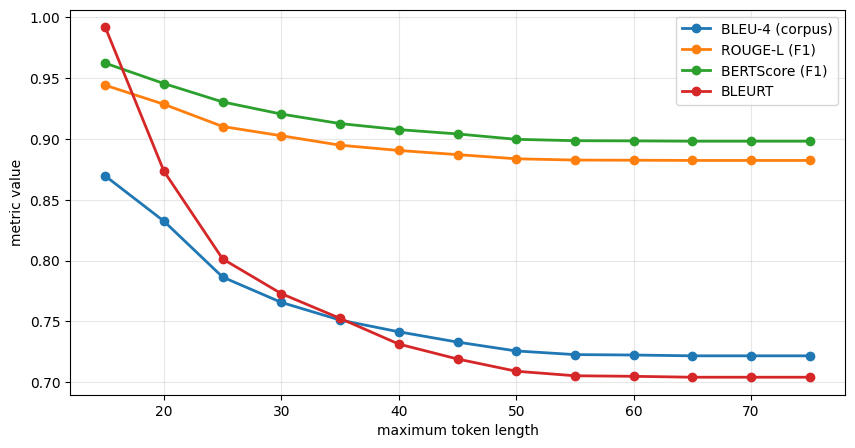

In [29]:
plt.figure(figsize=(10, 5))
for metric, color in zip(metrics, colors):
    plt.plot(df['threshold'], df[metric], marker='o', label=metric, color=color, linewidth=2)

plt.xlabel('maximum token length')
plt.ylabel('metric value')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('normalized_metrics_vs_word_count_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

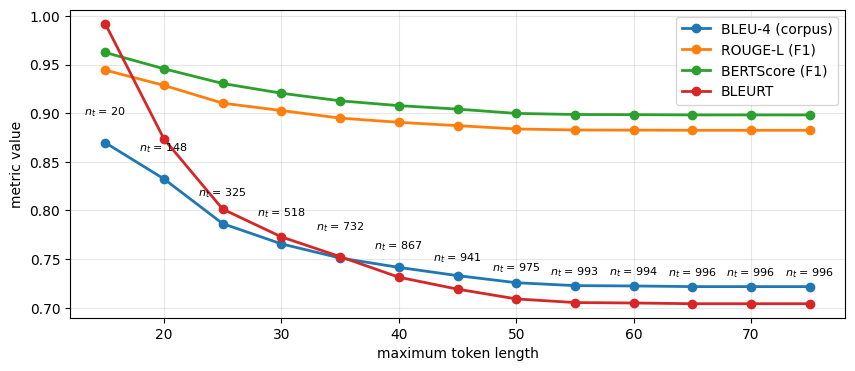

: 

In [ ]:
plt.figure(figsize=(10, 4))
for metric, color in zip(metrics, colors):
    plt.plot(df['threshold'], df[metric], marker='o', label=metric, color=color, linewidth=2)

for i, threshold in enumerate(df['threshold']):
    num_texts = df['num_texts'].iloc[i]
    y_pos = min(df[metric].iloc[i] for metric in metrics) + 0.025
    plt.annotate(r"$n_t$" + f" = {num_texts}", 
                xy=(threshold, y_pos),
                ha='center', 
                va='bottom',
                fontsize=8)

plt.xlabel('maximum token length')
plt.ylabel('metric value')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig('normalized_metrics_vs_word_count_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

#### Metrics for latent space clustering

In [176]:
import os
import json
import numpy as np
from tqdm import tqdm


def read_json_files(directory, file_limit=None):
    texts = []
    labels = []
    i = 1
    for filename in os.listdir(directory):
        if file_limit and i >= file_limit:
            break
        if filename.endswith('.json'):
            with open(os.path.join(directory, filename), 'r') as file:
                data = json.load(file)
                file_texts = data.get('text', [])
                if len(file_texts) != 5:
                    continue
                if any(len(text.split()) < 3 for text in file_texts):
                    continue
                texts.extend(file_texts)
                labels.extend([i] * len(file_texts))
                i += 1
    return texts, labels


def calculate_embeddings(texts, method='sonar'):
    if method == 'sonar':
        embeddings = []
        for text in tqdm(texts):
            embedding = get_sonar_embedding(text)
            embeddings.append(embedding.squeeze().cpu().numpy())
    elif method == 'clip':
        embeddings = calculate_clip_text_embeddings(texts)
    else:
        raise ValueError("Invalid method. Choose 'sonar' or 'clip'.")
    return np.array(embeddings)

In [177]:
directory = '../../dataset/reason_seg/ReasonSeg/test'
texts, labels = read_json_files(directory)# , file_limit=0)
len(texts)

790

In [171]:
embeddings_clip = calculate_embeddings(texts, method='clip')
embeddings_clip.shape

(790, 512)

In [172]:
embeddings_sonar = calculate_embeddings(texts, method='sonar')
embeddings_sonar.shape

100%|██████████| 790/790 [00:06<00:00, 116.43it/s]


(790, 1024)

In [178]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler


def recall_l2(dry_embeddings, labels):
    scaler = StandardScaler()
    embeddings = scaler.fit_transform(dry_embeddings)

    similarities = euclidean_distances(embeddings, embeddings)
    total_recall = 0
    
    for i in range(len(embeddings)):
        same_label_indices = [j for j in range(len(embeddings)) if labels[j] == labels[i] and i != j]
        
        sim_scores = [(j, similarities[i][j]) for j in range(len(embeddings)) if i != j]
        sim_scores.sort(key=lambda x: x[1])
        top_k_indices = [idx for idx, _ in sim_scores[:len(same_label_indices)]]
        
        matches = len(set(same_label_indices) & set(top_k_indices))

        recall = matches / (len(same_label_indices))
        total_recall += recall
    
    return total_recall / len(embeddings)


def cluster_separation_score(dry_embeddings, labels):
    scaler = StandardScaler()
    embeddings = scaler.fit_transform(dry_embeddings)
    
    unique_labels = set(labels)
    label_indices = {label: [i for i, l in enumerate(labels) if l == label] for label in unique_labels}
    
    centroids = {label: np.mean(embeddings[indices], axis=0) for label, indices in label_indices.items()}
    
    intra_cluster_distances = []
    for label, indices in label_indices.items():
        for idx in indices:
            distance = np.linalg.norm(embeddings[idx] - centroids[label])
            intra_cluster_distances.append(distance)

    avg_intra_distance = np.mean(intra_cluster_distances)
    
    inter_cluster_distances = []
    centroid_list = list(centroids.items())
    for i in range(len(centroid_list)):
        for j in range(i+1, len(centroid_list)):
            _, centroid1 = centroid_list[i]
            _, centroid2 = centroid_list[j]
            distance = np.linalg.norm(centroid1 - centroid2)
            inter_cluster_distances.append(distance)
    
    avg_inter_distance = np.mean(inter_cluster_distances) if inter_cluster_distances else 0
    
    return avg_intra_distance / avg_inter_distance


In [179]:
import numpy as np
import matplotlib.pyplot as plt


def evaluate_embeddings(embeddings, labels):
    return {
        'recall_l2': recall_l2(embeddings, labels),  # higher better
        'cluster_separation': cluster_separation_score(embeddings, labels) # lower better
    }

In [180]:
evaluate_embeddings(embeddings_clip, labels)

{'recall_l2': 0.9727848101265822, 'cluster_separation': 0.2879915}

In [181]:
evaluate_embeddings(embeddings_sonar, labels)

{'recall_l2': 0.7914556962025316, 'cluster_separation': 0.49413717}

##### final graph

In [182]:
def filter_text_groups_by_max_length(texts, labels, max_length):
    from collections import defaultdict
    
    grouped_texts = defaultdict(list)
    for text, label in zip(texts, labels):
        grouped_texts[label].append(text)
    
    filtered_texts = []
    filtered_labels = []
    
    for label, text_group in grouped_texts.items():
        if all(len(text.split()) <= max_length for text in text_group):
            filtered_texts.extend(text_group)
            filtered_labels.extend([label] * len(text_group))
    
    print(f"Kept {len(filtered_texts)} out of {len(texts)} texts ({len(set(filtered_labels))} out of {len(set(labels))} groups)")
    
    return filtered_texts, filtered_labels

In [183]:
# thresholds = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55]
thresholds = [10, 15, 20, 25, 30, 35]
results = []

for threshold in thresholds:
    filtered_texts, filtered_labels = filter_text_groups_by_max_length(texts, labels, max_length=threshold)
    
    if len(filtered_texts) < 10:
        continue
        
    embeddings_clip = calculate_embeddings(filtered_texts, method='clip')
    embeddings_sonar = calculate_embeddings(filtered_texts, method='sonar')
    
    clip_metrics = evaluate_embeddings(embeddings_clip, filtered_labels)
    sonar_metrics = evaluate_embeddings(embeddings_sonar, filtered_labels)
    
    results.append({
        'threshold': threshold,
        'num_texts': len(filtered_texts),
        'num_groups': len(set(filtered_labels)),
        'clip_recall_l2': clip_metrics['recall_l2'],
        'clip_cluster_separation': clip_metrics['cluster_separation'],
        'sonar_recall_l2': sonar_metrics['recall_l2'],
        'sonar_cluster_separation': sonar_metrics['cluster_separation']
    })

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

Kept 0 out of 790 texts (0 out of 158 groups)
Kept 30 out of 790 texts (6 out of 158 groups)


100%|██████████| 30/30 [00:00<00:00, 118.64it/s]


Kept 105 out of 790 texts (21 out of 158 groups)


100%|██████████| 105/105 [00:00<00:00, 117.84it/s]


Kept 290 out of 790 texts (58 out of 158 groups)


...

Kept 480 out of 790 texts (96 out of 158 groups)


100%|██████████| 480/480 [00:04<00:00, 117.60it/s]


Kept 650 out of 790 texts (130 out of 158 groups)


100%|██████████| 650/650 [00:05<00:00, 114.29it/s]


   threshold  num_texts  num_groups  clip_recall_l2  clip_cluster_separation  \
0         15         30           6        0.991667                 0.366692   
1         20        105          21        0.990476                 0.290334   
2         25        290          58        0.971552                 0.298834   
3         30        480          96        0.971354                 0.298318   
4         35        650         130        0.974615                 0.297376   

   sonar_recall_l2  sonar_cluster_separation  
0         0.891667                  0.460643  
1         0.942857                  0.436136  
2         0.888793                  0.459233  
3         0.818750                  0.486191  
4         0.792692                  0.503113  


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axs[0].plot(results_df['threshold'], results_df['clip_recall_l2'], 'o-', 
         color='#1f77b4', linewidth=2, markersize=8, label='CLIP')
axs[0].plot(results_df['threshold'], results_df['sonar_recall_l2'], 'o-', 
         color='#ff7f0e', linewidth=2, markersize=8, label='Sonar')

for i, row in results_df.iterrows():
    axs[0].annotate(f"{row['num_texts']} texts\n{row['num_groups']} groups", 
                 xy=(row['threshold'], min(row['clip_recall_l2'], row['sonar_recall_l2']) - 0.03),
                 ha='center', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

axs[0].set_title('Recall@L2 by Max Word Count Threshold', fontsize=14)
axs[0].set_ylabel('Recall@L2', fontsize=12)
axs[0].set_ylim(0.7, 1.02)  # Adjust as needed
axs[0].legend(loc='lower left', fontsize=12)
axs[0].grid(True, alpha=0.3)
axs[0].text(0.02, 0.98, "Higher is better", transform=axs[0].transAxes, 
         fontsize=11, va='top', 
         bbox=dict(boxstyle="round,pad=0.3", fc="#d3f0d3", ec="green", alpha=0.8))

axs[1].plot(results_df['threshold'], results_df['clip_cluster_separation'], 'o-', 
         color='#1f77b4', linewidth=2, markersize=8, label='CLIP')
axs[1].plot(results_df['threshold'], results_df['sonar_cluster_separation'], 'o-', 
         color='#ff7f0e', linewidth=2, markersize=8, label='Sonar')

axs[1].set_title('Cluster Separation by Max Word Count Threshold', fontsize=14)
axs[1].set_xlabel('Maximum Word Count Threshold', fontsize=12)
axs[1].set_ylabel('Cluster Separation', fontsize=12)
axs[1].set_xticks(results_df['threshold'])
axs[1].legend(loc='upper right', fontsize=12)
axs[1].grid(True, alpha=0.3)
axs[1].text(0.02, 0.98, "Lower is better", transform=axs[1].transAxes, 
         fontsize=11, va='top', 
         bbox=dict(boxstyle="round,pad=0.3", fc="#f0d3d3", ec="red", alpha=0.8))

plt.tight_layout()
plt.savefig('embedding_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

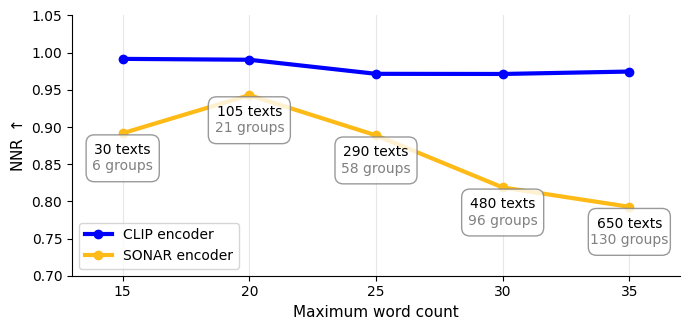

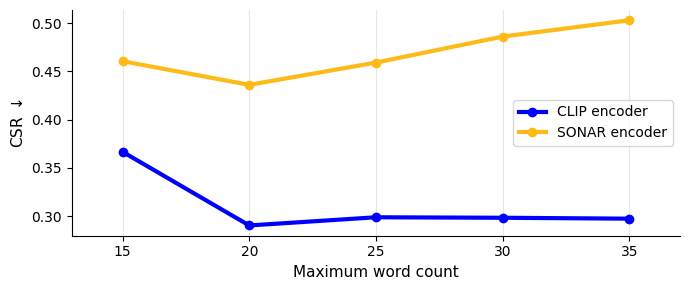

In [223]:
import matplotlib.pyplot as plt

# --- Recall@L2 plot ---

colors = ['blue', '#FEBA17']

plt.figure(figsize=(7, 3.4))

plt.plot(results_df['threshold'], results_df['clip_recall_l2'], 'o-', 
         color=colors[0], linewidth=3, markersize=6, label='CLIP encoder')
plt.plot(results_df['threshold'], results_df['sonar_recall_l2'], 'o-', 
         color=colors[1], linewidth=3, markersize=6, label='SONAR encoder')

for i, row in results_df.iterrows():
    plt.annotate(f"{int(row['num_texts'])} texts\n", 
                 xy=(row['threshold'], min(row['clip_recall_l2'], row['sonar_recall_l2']) - 0.05),
                 ha='center', 
                 bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="gray", alpha=0.8),
                 fontsize=10,
                 color='black',
                 annotation_clip=True)
    plt.annotate(f"{int(row['num_groups'])} groups", 
                 xy=(row['threshold'], min(row['clip_recall_l2'], row['sonar_recall_l2']) - 0.05),
                 ha='center', 
                 bbox=None,
                 fontsize=10,
                 color='gray',
                 annotation_clip=True)

plt.xlabel('Maximum word count', fontsize=11)
plt.ylabel(r'NNR $\uparrow$', fontsize=11)
plt.ylim(0.7, 1.05)
plt.xlim(13, 37)

plt.legend(loc='lower left', fontsize=10)
plt.grid(axis='x', alpha=0.3)  # Only vertical grid lines

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(results_df['threshold'].astype(int))
plt.tight_layout()
plt.savefig('sonar_clip_l2.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- Cluster Separation plot ---
plt.figure(figsize=(7, 3))
plt.plot(results_df['threshold'], results_df['clip_cluster_separation'], 'o-', 
         color=colors[0], linewidth=3, markersize=6, label='CLIP encoder')
plt.plot(results_df['threshold'], results_df['sonar_cluster_separation'], 'o-', 
         color=colors[1], linewidth=3, markersize=6, label='SONAR encoder')

plt.xlabel('Maximum word count', fontsize=11)
plt.ylabel(r'CSR $\downarrow$', fontsize=11)
plt.xticks(results_df['threshold'])
plt.legend(fontsize=10)
plt.grid(axis='x', alpha=0.3)  # Only vertical grid lines

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlim(13, 37)

plt.tight_layout()
plt.savefig('sonar_clip_CS.pdf', dpi=300, bbox_inches='tight')
plt.show()

### gpt-4o

In [52]:
def read_paraphrases(file_path):
    texts = []
    labels = []
    with open(file_path, 'r') as file:
        data = json.load(file)
        for i, (key, paraphrases) in enumerate(data.items()):
            texts.extend(paraphrases)
            labels.extend([i] * len(paraphrases))
    return texts, labels

In [53]:
file_path = './paraphrases.json'
texts, labels = read_paraphrases(file_path)

In [56]:
embeddings = calculate_embeddings(texts)

100%|██████████| 125/125 [00:01<00:00, 109.48it/s]


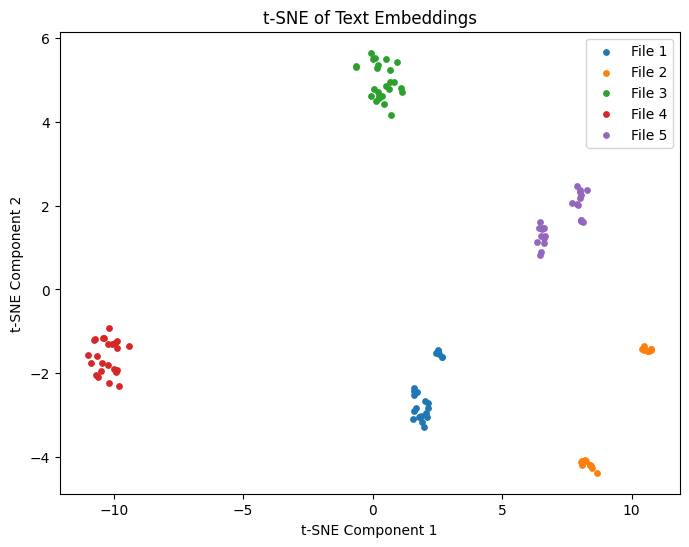

In [65]:
plot_tsne(embeddings, labels)

### success rate VS max sentence length

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# path = '../experiments/new-sonar/best_filter.csv'
method = 'GBDA-exp'
path = '/home/jovyan/zinkovich/ref-seg-text-break/experiments/new-sonar-exp/best_filter.csv'
# path = '../experiments/new-sonar-exp-lr/best_filter.csv'
df = pd.read_csv(path)

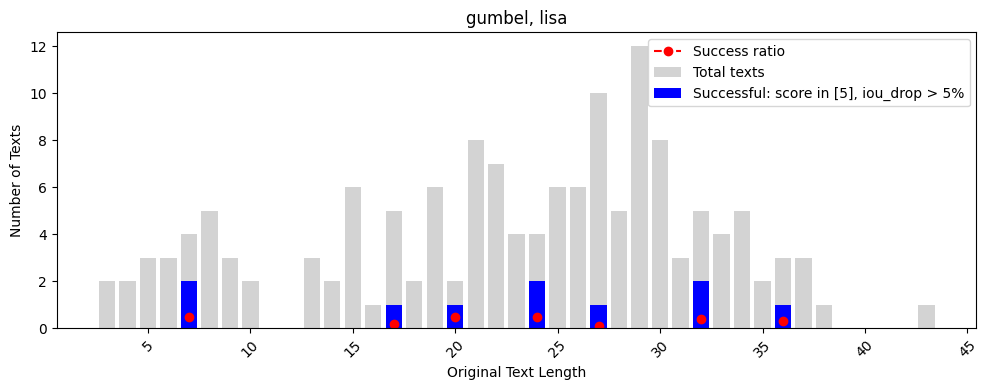

In [55]:
lim_iou = 0.05
lim_score = [5]

unique_df = df.drop_duplicates(subset='sample_idx')
unique_df['orig_text_length'] = unique_df['orig_text'].apply(lambda x: len(x.split()))

df['orig_text_length'] = df['orig_text'].apply(lambda x: len(x.split()))
df['is_successful'] = ((df['orig_iou'] - df['adv_iou']) / df['orig_iou'] > lim_iou) & (df['SCORE_nvidia/Llama-3.1-Nemotron-70B-Instruct-HF'].isin(lim_score))

success_counts = df[df['is_successful']].groupby('orig_text_length').size()
total_counts = unique_df.groupby('orig_text_length').size()

success_ratio = success_counts / total_counts

plt.figure(figsize=(10, 4))
plt.bar(total_counts.index, total_counts.values, color='lightgray', label='Total texts')
plt.bar(success_counts.index, success_counts.values, color='blue', label=f'Successful: score in {lim_score}, iou_drop > {lim_iou * 100:.0f}%')

plt.plot(success_ratio.index, success_ratio.values, color='red', marker='o', label='Success ratio', linestyle='--')

plt.xlabel('Original Text Length')
plt.ylabel('Number of Texts')
plt.title('gumbel, lisa')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('gumbel_lisa.png', dpi=300)
plt.show()

/tmp/ipykernel_1676642/3335708654.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_counts = df[df['is_successful']].groupby('text_length_bin').size()
/tmp/ipykernel_1676642/3335708654.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = unique_df.groupby('text_length_bin').size()


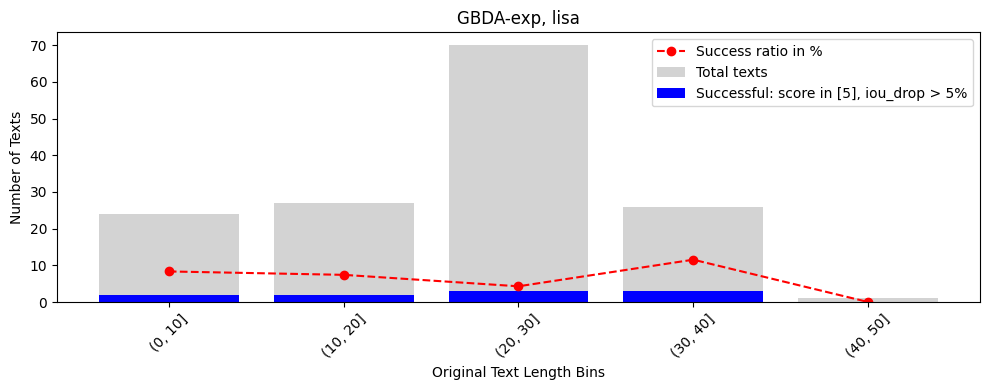

In [56]:
bin_edges = [0, 10, 20, 30, 40, 50]  # Adjust these values as needed

unique_df['text_length_bin'] = pd.cut(unique_df['orig_text_length'], bins=bin_edges)
df['text_length_bin'] = pd.cut(df['orig_text_length'], bins=bin_edges)


success_counts = df[df['is_successful']].groupby('text_length_bin').size()
total_counts = unique_df.groupby('text_length_bin').size()

success_ratio = success_counts / total_counts

# Plotting
plt.figure(figsize=(10, 4))
plt.bar(total_counts.index.astype(str), total_counts.values, color='lightgray', label='Total texts')
plt.bar(success_counts.index.astype(str), success_counts.values, color='blue', label=f'Successful: score in {lim_score}, iou_drop > {lim_iou * 100:.0f}%')

plt.plot(success_ratio.index.astype(str), success_ratio.values * 100, color='red', marker='o', label='Success ratio in %', linestyle='--')

plt.xlabel('Original Text Length Bins')
plt.ylabel('Number of Texts')
plt.title(f'{method}, lisa')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(f'{method}_lisa.png', dpi=300)
plt.show()

In [57]:
success_ratio.values * 100

array([ 8.33333333,  7.40740741,  4.28571429, 11.53846154,  0.        ])

### Sonar VS LISA tokens 

#### ReasonSeg data

In [1]:
import os
import json

json_dir = "/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break/dataset/reason_seg/ReasonSeg/test"

texts = []

for filename in os.listdir(json_dir):
    if filename.endswith(".json"):
        file_path = os.path.join(json_dir, filename)
        with open(file_path, 'r') as f:
            data = json.load(f)
            if "text" in data:
                texts.extend(data["text"])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")


Extracted texts:
Total number of texts: 3408


#### LISA tokens

In [ ]:
from transformers import AutoTokenizer

lisa_tokenizer = AutoTokenizer.from_pretrained(
    "xinlai/LISA-13B-llama2-v1",
    use_fast=False,
    add_eos_token=True
)
lisa_tokenizer.pad_token = lisa_tokenizer.unk_token

/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
def lisa_tokenize(text):
    return lisa_tokenizer.encode(text, add_special_tokens=False)

def lisa_decode(tokens):
    return lisa_tokenizer.decode(tokens, skip_special_tokens=True)

text = "Hello, world!"
lisa_tokenize(text)

[15043, 29892, 3186, 29991]

#### SONAR tokens

In [5]:
def sonar_tokenize(text):
    return sonar_t2v.tokenizer.create_encoder(lang="eng_Latn")(text)[1:-1].tolist()

def sonar_decode(tokens):
    return str(sonar_t2v.tokenizer.create_decoder()(torch.tensor(tokens)))

text = "Hello, world!"
sonar_tokenize(text)

[94124, 248079, 15697, 248203]

In [5]:
sonar_tokenizer = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')

In [14]:
sonar_t2v.tokenizer.vocab_info.size

256206

In [11]:
sonar_tokenizer

#### Comparison

##### overall lisa vocab

In [76]:
import numpy as np

n_special_tokens = np.arange(0, 260)
n_lisa_tokens = 0

matches = {}
mismatches = {}

for lisa_subword, i in lisa_tokenizer.get_vocab().items():
    if i in n_special_tokens:
        continue
    else:
        sonar_tokens = sonar_tokenize(lisa_subword)
        if len(sonar_tokens) == 0:
            continue
        if len(sonar_tokens) == 1:
            matches[lisa_subword] = {
                'sonar_token': sonar_tokens[0],
                'lisa_token' : i
            }
        else:
            mismatches[lisa_subword] = {
                'sonar_tokens': sonar_tokens,
                'lisa_token' : i
            }
        n_lisa_tokens += 1

In [77]:
print(f'matches: {len(matches)} out of {n_lisa_tokens}, p = {len(matches)/n_lisa_tokens * 100:.0f}%')

matches: 19443 out of 31707, p = 61%


In [81]:
s = {}
for key, value in mismatches.items():
    length = len(value['sonar_tokens'])
    s[length] = s.get(length, 0) + 1

In [87]:
sorted(s.items(), key=lambda x: x[0])

[(2, 10829), (3, 1230), (4, 158), (5, 36), (6, 6), (7, 1), (8, 3), (16, 1)]

##### only reasonseg data

In [ ]:
lisa_rs_tokens = {}

for text in texts:
    for word in text.split():
        lisa_tokens = lisa_tokenize(word)
        for token in lisa_tokens:
            
            lisa_rs_tokens[word] = token

In [146]:
lisa_rs_tokens = {}

for text in texts:
    for word in text.split():
        sonar_tokens = sonar_tokenize(word)
        for token in sonar_tokens:
            subword = sonar_decode([token])
            
        break


In [148]:
subword

'While'

In [145]:
lisa_subwords

['tea', 'xt', 'x']

In [101]:
lisa_tokenizer.get_vocab()

{'<unk>': 0,
 '<s>': 1,
 '</s>': 2,
 '<0x00>': 3,
 '<0x01>': 4,
 '<0x02>': 5,
 '<0x03>': 6,
 '<0x04>': 7,
 '<0x05>': 8,
 '<0x06>': 9,
 '<0x07>': 10,
 '<0x08>': 11,
 '<0x09>': 12,
 '<0x0A>': 13,
 '<0x0B>': 14,
 '<0x0C>': 15,
 '<0x0D>': 16,
 '<0x0E>': 17,
 '<0x0F>': 18,
 '<0x10>': 19,
 '<0x11>': 20,
 '<0x12>': 21,
 '<0x13>': 22,
 '<0x14>': 23,
 '<0x15>': 24,
 '<0x16>': 25,
 '<0x17>': 26,
 '<0x18>': 27,
 '<0x19>': 28,
 '<0x1A>': 29,
 '<0x1B>': 30,
 '<0x1C>': 31,
 '<0x1D>': 32,
 '<0x1E>': 33,
 '<0x1F>': 34,
 '<0x20>': 35,
 '<0x21>': 36,
 '<0x22>': 37,
 '<0x23>': 38,
 '<0x24>': 39,
 '<0x25>': 40,
 '<0x26>': 41,
 '<0x27>': 42,
 '<0x28>': 43,
 '<0x29>': 44,
 '<0x2A>': 45,
 '<0x2B>': 46,
 '<0x2C>': 47,
 '<0x2D>': 48,
 '<0x2E>': 49,
 '<0x2F>': 50,
 '<0x30>': 51,
 '<0x31>': 52,
 '<0x32>': 53,
 '<0x33>': 54,
 '<0x34>': 55,
 '<0x35>': 56,
 '<0x36>': 57,
 '<0x37>': 58,
 '<0x38>': 59,
 '<0x39>': 60,
 '<0x3A>': 61,
 '<0x3B>': 62,
 '<0x3C>': 63,
 '<0x3D>': 64,
 '<0x3E>': 65,
 '<0x3F>': 66,
 '<0x40>': 

In [97]:
for text in texts:
    for word in text.split():
        lisa_tokens = lisa_tokenize(word)
        sonar_tokens = sonar_tokenize(word)
        if len(lisa_tokens) == len(sonar_tokens):
            for l, s in zip(lisa_tokens, sonar_tokens):
                matches[l] = s.item()
        else:

3408

In [ ]:
import numpy as np

n_special_tokens = np.arange(0, 260)
n_lisa_tokens = 0

matches = {}
mismatches = {}

for lisa_subword, i in lisa_tokenizer.get_vocab().items():
    if i in n_special_tokens:
        continue
    else:
        sonar_tokens = sonar_tokenize(lisa_subword)
        if len(sonar_tokens) == 0:
            continue
        if len(sonar_tokens) == 1:
            matches[lisa_subword] = {
                'sonar_token': sonar_tokens[0],
                'lisa_token' : i
            }
        else:
            mismatches[lisa_subword] = {
                'sonar_tokens': sonar_tokens,
                'lisa_token' : i
            }
        n_lisa_tokens += 1